# 06 · Modelo de difusión condicional

**Taller B5-T1 · Generación de datos financieros sintéticos**

Tercero de los tres modelos generativos neuronales del proyecto, y el más
distinto de los otros dos. Ni enfrenta dos redes como el cGAN ni comprime la
ventana en un espacio latente como el CVAE: aprende a deshacer, paso a paso, un
proceso de degradación conocido.

**Salidas:** `models/sinteticos_diffusion.npz` y
`results/tablas/resultados_diffusion.csv`

## Preparación del entorno

Se fija el backend de cómputo, se añade el código común del proyecto a la ruta
de importación y se aplica el estilo gráfico compartido. El bloque funciona sin
cambios tanto en una instalación local como en Colab.

In [1]:
import os
import sys

# Keras 3 se ejecuta sobre PyTorch: la versión de Python empleada no dispone de
# TensorFlow y la API de capas y modelos es idéntica en ambos backends.
os.environ["KERAS_BACKEND"] = "torch"

EN_COLAB = "google.colab" in sys.modules

if EN_COLAB:
    !pip install -q yfinance keras torch
    # En Colab se asume que el repositorio está clonado en el directorio actual.
    RAIZ = "/content/B5-T1"
else:
    RAIZ = os.path.dirname(os.getcwd())

if os.path.join(RAIZ, "src") not in sys.path:
    sys.path.insert(0, os.path.join(RAIZ, "src"))

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from miax_b5t1 import config, datos, experimento, graficos, modelo

graficos.aplicar_estilo()
config.asegurar_directorios()

print(f"Keras {keras.__version__} sobre backend {keras.backend.backend()}")
print(f"Raíz del proyecto: {RAIZ}")

Keras 3.15.1 sobre backend torch
Raíz del proyecto: C:\Users\piett\OneDrive\Desktop\Pietro\Master MIAX\Clases\5\tareas\B5-T1


## 1. Datos de partida

Se carga el dataset y se extrae el presupuesto de datos reales fijado en el
notebook 02.

**El generador se entrena únicamente con `X_real` e `y_real`.** No debe emplearse
el conjunto de entrenamiento completo, ni validación, ni test. Si el generador
accede a datos que el clasificador no tiene, la comparación pierde validez.

In [2]:
d = datos.cargar_dataset()

X_real, y_real = datos.submuestra_real(
    d["X_train"], d["y_train"], config.N_REALES, config.SEMILLA)

X_val, y_val = d["X_val"], d["y_val"]
X_test, y_test = d["X_test"], d["y_test"]

n_pasos, n_activos = X_real.shape[1], X_real.shape[2]
DIMENSION = n_pasos * n_activos
X_plano = X_real.reshape(len(X_real), DIMENSION)

print(f"Presupuesto real: {X_real.shape}")
print(f"Positivas: {int(y_real.sum())} ({y_real.mean():.1%})")
print(f"Dimensión de la ventana aplanada: {DIMENSION}")

Presupuesto real: (3000, 60, 23)
Positivas: 301 (10.0%)
Dimensión de la ventana aplanada: 1380


## 2. Fundamento del modelo

El modelo se apoya en dos procesos. El **directo** toma una ventana real y le
añade ruido gaussiano de forma progresiva a lo largo de `T` pasos, hasta que no
queda nada de la señal original. No tiene parámetros: la cantidad de ruido de
cada paso viene fijada de antemano por una planificación de la varianza, y como
la suma de gaussianas es gaussiana, puede saltarse directamente al paso `t` que
se quiera sin recorrer los anteriores.

El **inverso** es lo único que se entrena. Una red recibe una ventana ruidosa y
el instante del proceso en que se encuentra, y estima la ventana limpia de la que
procede. Generar una muestra nueva consiste en partir de ruido puro y aplicar esa
red de forma iterativa: en cada paso se estima la ventana limpia, se retrocede un
instante hacia ella y se vuelve a empezar. Equivale a decir que quitar ruido a un dato lo desplaza hacia donde la
probabilidad es mayor, repetido hasta que el dato aterriza sobre la
distribución de los reales.

El instante `t` entra en la red mediante una incrustación sinusoidal, porque la
misma ventana ruidosa significa cosas distintas según cuánto ruido lleve
acumulado: sin esa información la red no puede saber cuánto tiene que corregir.
El condicionamiento por la etiqueta se añade concatenandola a la entrada, igual
que en el cGAN y en el CVAE, de modo que se pueden pedir muestras de la clase
positiva de forma explícita.

**Una decisión se aparta de la receta habitual y conviene justificarla:** la red
estima la ventana limpia y no el ruido añadido. La formulación clásica predice
el ruido, y funciona cuando la señal es recuperable a partir del dato ruidoso.
Aquí no lo es. El análisis exploratorio mostró que la autocorrelación de las
rentabilidades diarias es de 0,019: la serie es casi ruido blanco en la
dirección temporal. Estimar el ruido en ese régimen resulta prácticamente
imposible, y como el paso inverso divide por la raíz del coeficiente de la
planificación, un estimador mediocre hace que el proceso diverja.

No es una conjetura: con la formulación por ruido el error cuadrático se quedaba
en 0,80 sobre un máximo de 1,00 —una red que devolviese cero obtiene 1,00— y
las muestras salían saturadas en los extremos del intervalo. Estimando la ventana
limpia el error baja hasta 0,34, la salida queda acotada y recortarla en cada
paso mantiene el muestreo estable.

Sobre qué cabe esperar: la difusión suele reproducir bien las colas pesadas, pero
su muestreo es mucho más caro que el de los otros generadores, porque cada
muestra exige recorrer los `T` pasos del proceso inverso.

## 3. Arquitectura

La planificación de la varianza es lineal, con `T` pasos, y los coeficientes
acumulados se precalculan antes del bucle de entrenamiento para no repetir el
producto en cada iteración.

La red es densa sobre la ventana aplanada, con la misma justificación que en el
cGAN, y recibe tres entradas que se concatenan: la ventana ruidosa, la
incrustación sinusoidal del paso y la etiqueta. La salida no lleva activación,
porque estima una ventana y no una probabilidad.

**Los datos se normalizan a varianza unidad antes del proceso.** El escalador del
proyecto lleva las rentabilidades al intervalo `[-1, 1]` dividiendo por cuatro
desviaciones típicas, de modo que su dispersión efectiva es de 0,24. La difusión
supone datos de varianza unidad, y con 0,24 el ruido domina en todos los pasos y
la señal desaparece. La normalización se deshace al generar.

In [3]:
import time

import torch
from keras import Model, layers

T_DIFUSION = 200      # pasos del proceso
DIM_EMB = 64          # dimension de la incrustacion temporal
UNIDADES = 768        # anchura de las capas densas

# --- Normalizacion a varianza unidad -------------------------------------
ESCALA = float(X_plano.std())
X0 = (X_plano / ESCALA).astype("float32")
LIMITE = float(np.abs(X0).max())

# --- Planificacion de la varianza ----------------------------------------
betas = np.linspace(1e-4, 0.02, T_DIFUSION).astype("float32")
alphas = (1.0 - betas).astype("float32")
acum = np.cumprod(alphas).astype("float32")
acum_ant = np.concatenate([[1.0], acum[:-1]]).astype("float32")
raiz_acum = np.sqrt(acum)
raiz_1m = np.sqrt(1.0 - acum)

# --- Incrustacion sinusoidal del paso, precalculada ----------------------
posiciones = np.arange(T_DIFUSION)[:, None]
frecuencias = np.exp(np.arange(0, DIM_EMB, 2) * -(np.log(10000.0) / DIM_EMB))[None, :]
EMB = np.zeros((T_DIFUSION, DIM_EMB), dtype="float32")
EMB[:, 0::2] = np.sin(posiciones * frecuencias)
EMB[:, 1::2] = np.cos(posiciones * frecuencias)

# --- Red estimadora de la ventana limpia ---------------------------------
keras.utils.set_random_seed(config.SEMILLA)

entrada_x = layers.Input(shape=(DIMENSION,), name="ventana_ruidosa")
entrada_t = layers.Input(shape=(DIM_EMB,), name="paso")
entrada_y = layers.Input(shape=(1,), name="etiqueta")

h = layers.Concatenate()([entrada_x, entrada_t, entrada_y])
for _ in range(3):
    h = layers.Dense(UNIDADES, activation="silu")(h)
salida = layers.Dense(DIMENSION, name="ventana_limpia")(h)

estimador = Model([entrada_x, entrada_t, entrada_y], salida, name="estimador_x0")
estimador.compile(optimizer=keras.optimizers.Adam(2e-4), loss="mse")
estimador.summary()

print()
print(f"Escala de difusion: {ESCALA:.4f}"
      f"   (desviacion tras normalizar: {X0.std():.4f})")
print(f"Recorte de la ventana estimada: +-{LIMITE:.2f}")

Model: "estimador_x0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ventana_ruidosa     │ (None, 1380)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ paso (InputLayer)   │ (None, 64)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ etiqueta            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1445)      │          0 │ ventana_ruidosa[… │
│ (Concatenate)       │                   │            │ paso[0][0],       │
│                     │                   │            │ etiqueta[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 768)       │  1,110,528 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 768)       │    590,592 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 768)       │    590,592 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ventana_limpia      │ (None, 1380)      │  1,061,220 │ dense_2[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,352,932 (12.79 MB)

 Trainable params: 3,352,932 (12.79 MB)

 Non-trainable params: 0 (0.00 B)


Escala de difusion: 0.2408   (desviacion tras normalizar: 1.0000)
Recorte de la ventana estimada: +-4.15


## 4. Entrenamiento

Cada iteración toma un lote de ventanas reales, sortea un paso distinto para cada
una, les añade el ruido que corresponde a ese paso y entrena la red a recuperar
la ventana original. El error cuadrático medio entre la ventana limpia y la
estimada es la única pérdida.

A diferencia del esquema adversario del notebook 04, aquí la pérdida sí debe
descender de forma clara y sostenida. El valor de partida es informativo: una red
que devolviese siempre la media daría un error cercano a 1,00, porque los datos
están normalizados a varianza unidad.

In [4]:
EPOCHS_DIFUSION = 1000
LOTE_DIFUSION = 64

rng = np.random.default_rng(config.SEMILLA)
historial_perdida = []
t_inicio = time.time()

for epoca in range(EPOCHS_DIFUSION):
    orden = rng.permutation(len(X0))
    perdidas_epoca = []

    for i in range(0, len(X0), LOTE_DIFUSION):
        idx = orden[i:i + LOTE_DIFUSION]
        ventanas = X0[idx]
        etiquetas = y_real[idx].reshape(-1, 1)

        pasos = rng.integers(0, T_DIFUSION, len(idx))
        ruido = rng.normal(size=ventanas.shape).astype("float32")
        ruidosas = (raiz_acum[pasos][:, None] * ventanas
                    + raiz_1m[pasos][:, None] * ruido)

        perdidas_epoca.append(float(estimador.train_on_batch(
            [ruidosas, EMB[pasos], etiquetas], ventanas)))

    historial_perdida.append(float(np.mean(perdidas_epoca)))

    if epoca % 100 == 0 or epoca == EPOCHS_DIFUSION - 1:
        print(f"epoca {epoca:>4d}   error {historial_perdida[-1]:.4f}"
              f"   ({(time.time() - t_inicio) / 60:.1f} min)")

print()
print(f"Entrenamiento finalizado en {(time.time() - t_inicio) / 60:.1f} minutos.")
print(f"Error inicial -> final: {historial_perdida[0]:.4f}"
      f" -> {historial_perdida[-1]:.4f}")

epoca    0   error 1.0053   (0.0 min)


epoca  100   error 0.4441   (1.8 min)


epoca  200   error 0.3976   (3.6 min)


epoca  300   error 0.3825   (5.5 min)


epoca  400   error 0.3683   (7.3 min)


...

epoca  600   error 0.3519   (10.9 min)


epoca  700   error 0.3486   (12.8 min)


epoca  800   error 0.3446   (14.7 min)


epoca  900   error 0.3385   (16.5 min)


epoca  999   error 0.3381   (18.3 min)

Entrenamiento finalizado en 18.3 minutos.
Error inicial -> final: 1.0053 -> 0.3381


## 5. Curva de convergencia y generación

Tras comprobar la convergencia se generan las muestras recorriendo el proceso
inverso. Conviene generar por lotes: recorrer todos los pasos del proceso para
cada muestra es la parte más costosa del notebook.

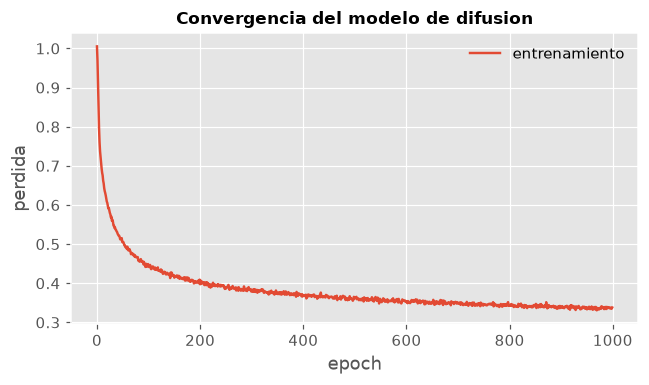

In [5]:
graficos.curva_perdida(
    {"loss": historial_perdida}, "Convergencia del modelo de difusion",
    "06_perdida_difusion", claves=("loss",))
plt.show()

### 5.1 El muestreo y su temperatura

El proceso inverso recorre los `T` pasos hacia atrás. En cada uno la red estima
la ventana limpia, esa estimación se recorta al rango de los datos reales, y se
retrocede un instante combinándola con la ventana actual según la media de la
posterior del proceso directo. Al final se deshace la normalización y se recorta
al intervalo `[-1, 1]` del escalador.

Queda una decisión. La varianza que el proceso inyecta en cada paso está
calculada suponiendo que la estimación de la ventana limpia es exacta. No lo es:
la red devuelve una estimación regularizada, y el ruido que se le suma encima
produce muestras más dispersas que los datos reales. Ese factor cumple el papel de una temperatura de
muestreo, y en lugar de fijarlo a ojo se recorre un barrido, igual que el
notebook 03 hace con la intensidad del ruido.

**El barrido no consigue lo que se esperaba de él, y conviene decirlo.** La
dispersión de las muestras apenas se mueve entre los extremos del rango
—de 0,39 con temperatura 0,2 a 0,46 con temperatura 1,0— mientras que la de los
datos reales es 0,24. El criterio elige por tanto el valor más bajo del barrido,
es decir, un extremo: señal inequívoca de que la temperatura no es la causa
dominante del exceso de dispersión.

La causa está en el estimador. La red produce ventanas sistemáticamente más
amplias que las reales, y bajar el ruido inyectado sólo recorta una fracción
pequeña de esa diferencia. Bajar la temperatura hasta cero eliminaría la
estocasticidad del muestreo —y con ella la diversidad entre muestras— sin
resolver el problema, de modo que se conserva 0,2, que mantiene el proceso
estocástico. La limitación queda documentada y se retoma en las conclusiones.

In [6]:
def muestrear(n_muestras, etiquetas, temperatura=1.0, lote=1000, semilla=None):
    """Recorre el proceso inverso y devuelve ventanas en la escala del dataset.

    `temperatura` multiplica el ruido que se inyecta en cada paso. Con 0 el
    muestreo es determinista dada la semilla inicial; con 1 se usa la varianza
    de la posterior tal cual la define el proceso.
    """
    generador = np.random.default_rng(config.SEMILLA if semilla is None else semilla)
    etiquetas = np.asarray(etiquetas, dtype="float32").reshape(-1, 1)
    trozos = []

    for inicio in range(0, n_muestras, lote):
        m = min(lote, n_muestras - inicio)
        x = generador.normal(size=(m, DIMENSION)).astype("float32")
        y_lote = etiquetas[inicio:inicio + m]

        with torch.no_grad():
            for t in range(T_DIFUSION - 1, -1, -1):
                emb_t = np.repeat(EMB[t][None, :], m, axis=0)
                x0_est = keras.ops.convert_to_numpy(
                    estimador([x, emb_t, y_lote], training=False))
                x0_est = np.clip(x0_est, -LIMITE, LIMITE)

                coef_x0 = np.sqrt(acum_ant[t]) * betas[t] / (1.0 - acum[t])
                coef_xt = np.sqrt(alphas[t]) * (1.0 - acum_ant[t]) / (1.0 - acum[t])
                x = coef_x0 * x0_est + coef_xt * x

                if t > 0 and temperatura > 0:
                    var = betas[t] * (1.0 - acum_ant[t]) / (1.0 - acum[t])
                    x = x + temperatura * np.sqrt(var) * generador.normal(
                        size=x.shape).astype("float32")

        trozos.append(x)

    bruto = np.concatenate(trozos) * ESCALA
    return np.clip(bruto, -1.0, 1.0).astype("float32")


print("Muestreador definido.")

Muestreador definido.


El barrido genera mil muestras con cada temperatura y mide la desviacion
tipica, el peso de las colas y la correlacion entre activos. La elegida es la
que menos se aparta de la dispersion de los datos reales.

In [7]:
from scipy import stats

TEMPERATURAS = [0.2, 0.4, 0.6, 0.8, 1.0]
N_CALIBRACION = 1000

corr_real = np.corrcoef(X_real.reshape(-1, n_activos).T)
triangulo = np.triu_indices(n_activos, k=1)
std_real = float(X_real.std())

etiquetas_cal = (rng.random(N_CALIBRACION) < float(y_real.mean())).astype("float32")

filas = []
for temperatura in TEMPERATURAS:
    muestras = muestrear(N_CALIBRACION, etiquetas_cal, temperatura=temperatura)
    cubo = muestras.reshape(-1, n_pasos, n_activos)
    corr = np.corrcoef(cubo.reshape(-1, n_activos).T)
    filas.append({
        "temperatura": temperatura,
        "desviacion tipica": float(muestras.std()),
        "curtosis": float(stats.kurtosis(muestras.ravel())),
        "correlacion media": float(corr[triangulo].mean()),
        "saturado (%)": 100 * float((np.abs(muestras) > 0.99).mean()),
        "error de dispersion": abs(float(muestras.std()) - std_real),
    })
    print(f"  temperatura {temperatura:.1f}  ->  desviacion "
          f"{filas[-1]['desviacion tipica']:.4f}  (real {std_real:.4f})")

tabla_temperatura = pd.DataFrame(filas)
TEMPERATURA = float(tabla_temperatura.loc[
    tabla_temperatura["error de dispersion"].idxmin(), "temperatura"])

print()
print(f"Temperatura elegida: {TEMPERATURA:.1f}")
display(tabla_temperatura.round(4))

  temperatura 0.2  ->  desviacion 0.3924  (real 0.2408)


  temperatura 0.4  ->  desviacion 0.4091  (real 0.2408)


  temperatura 0.6  ->  desviacion 0.4274  (real 0.2408)


  temperatura 0.8  ->  desviacion 0.4442  (real 0.2408)


  temperatura 1.0  ->  desviacion 0.4569  (real 0.2408)

Temperatura elegida: 0.2


,temperatura,desviacion tipica,curtosis,correlacion media,saturado (%),error de dispersion
0,0.2,0.3924,0.0263,0.4363,2.1157,0.1516
1,0.4,0.4091,-0.0930,0.4285,2.5462,0.1683
2,0.6,0.4274,-0.2069,0.4196,3.1190,0.1866
3,0.8,0.4442,-0.2986,0.4120,3.7765,0.2034
4,1.0,0.4569,-0.3654,0.4058,4.3475,0.2161


Las tres propiedades frente a la temperatura, con el valor real marcado en rojo
y la temperatura elegida en azul.

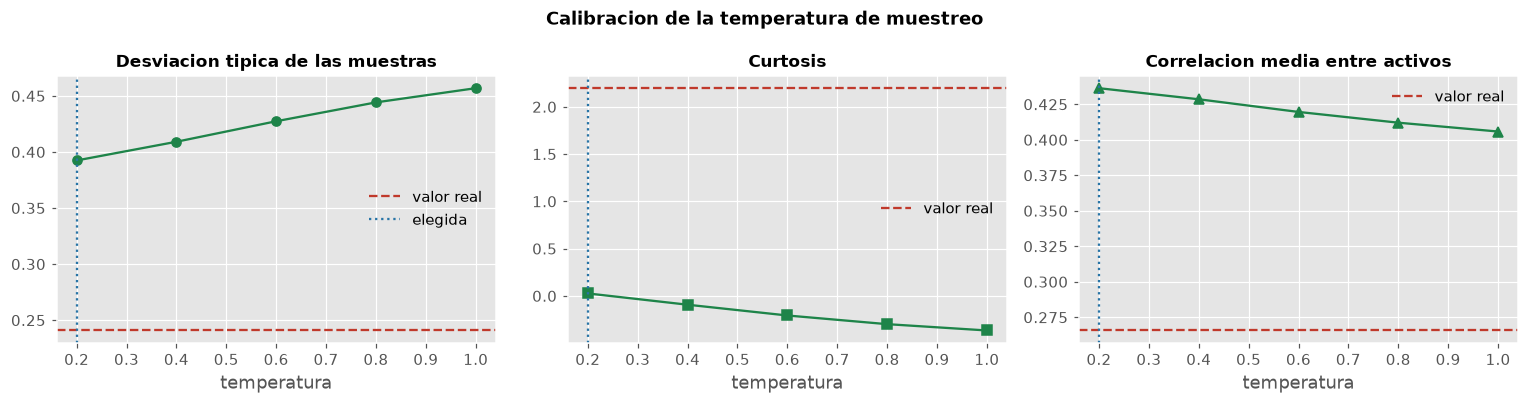

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.7))

axes[0].plot(tabla_temperatura["temperatura"],
             tabla_temperatura["desviacion tipica"], marker="o", color="#1e8449")
axes[0].axhline(std_real, color="#c0392b", linestyle="--", label="valor real")
axes[0].axvline(TEMPERATURA, color="#2874a6", linestyle=":", label="elegida")
axes[0].set_title("Desviacion tipica de las muestras")
axes[0].set_xlabel("temperatura")
axes[0].legend()

axes[1].plot(tabla_temperatura["temperatura"], tabla_temperatura["curtosis"],
             marker="s", color="#1e8449")
axes[1].axhline(float(stats.kurtosis(X_real.ravel())), color="#c0392b",
                linestyle="--", label="valor real")
axes[1].axvline(TEMPERATURA, color="#2874a6", linestyle=":")
axes[1].set_title("Curtosis")
axes[1].set_xlabel("temperatura")
axes[1].legend()

axes[2].plot(tabla_temperatura["temperatura"],
             tabla_temperatura["correlacion media"], marker="^", color="#1e8449")
axes[2].axhline(float(corr_real[triangulo].mean()), color="#c0392b",
                linestyle="--", label="valor real")
axes[2].axvline(TEMPERATURA, color="#2874a6", linestyle=":")
axes[2].set_title("Correlacion media entre activos")
axes[2].set_xlabel("temperatura")
axes[2].legend()

fig.suptitle("Calibracion de la temperatura de muestreo", fontweight="bold")
fig.tight_layout()
graficos.guardar(fig, "06_calibracion_temperatura")
plt.show()

Con la temperatura fijada se generan las muestras definitivas. Las etiquetas se
sortean con la misma tasa de positivos que los datos reales, y el número cubre el
ratio máximo del barrido posterior para que ninguna configuración tenga que
repetir muestras.

In [9]:
N_SINTETICOS = int(config.N_REALES * max(config.RATIOS_SINTETICOS))

y_synth = (rng.random(N_SINTETICOS) < float(y_real.mean())).astype("float32")

t_gen = time.time()
X_synth = muestrear(N_SINTETICOS, y_synth, temperatura=TEMPERATURA)
X_synth = X_synth.reshape(N_SINTETICOS, n_pasos, n_activos).astype("float32")

print(f"Muestras sinteticas: {X_synth.shape}")
print(f"Positivas: {int(y_synth.sum())} ({y_synth.mean():.1%})")
print(f"Rango: [{X_synth.min():.3f}, {X_synth.max():.3f}]")
print(f"Fraccion saturada en los extremos: "
      f"{100 * float((np.abs(X_synth) > 0.99).mean()):.3f} %")
print(f"Tiempo de muestreo: {(time.time() - t_gen) / 60:.1f} minutos "
      f"para {N_SINTETICOS} ventanas")

Muestras sinteticas: (12000, 60, 23)
Positivas: 1147 (9.6%)
Rango: [-1.000, 1.000]
Fraccion saturada en los extremos: 2.095 %
Tiempo de muestreo: 2.2 minutos para 12000 ventanas


## 6. Validación cualitativa

Antes de medir el efecto sobre el clasificador conviene comprobar si las muestras
generadas se parecen a ventanas de mercado reales. El análisis exploratorio
identifico tres propiedades que un generador debería reproducir: colas más
pesadas que las de una normal, agrupamiento de la volatilidad dentro de la
ventana y correlación positiva entre activos.

Conviene comprobar también que las trayectorias no sean planas ni esten saturadas
en los extremos del intervalo, dos síntomas habituales de un generador que no ha
convergido.

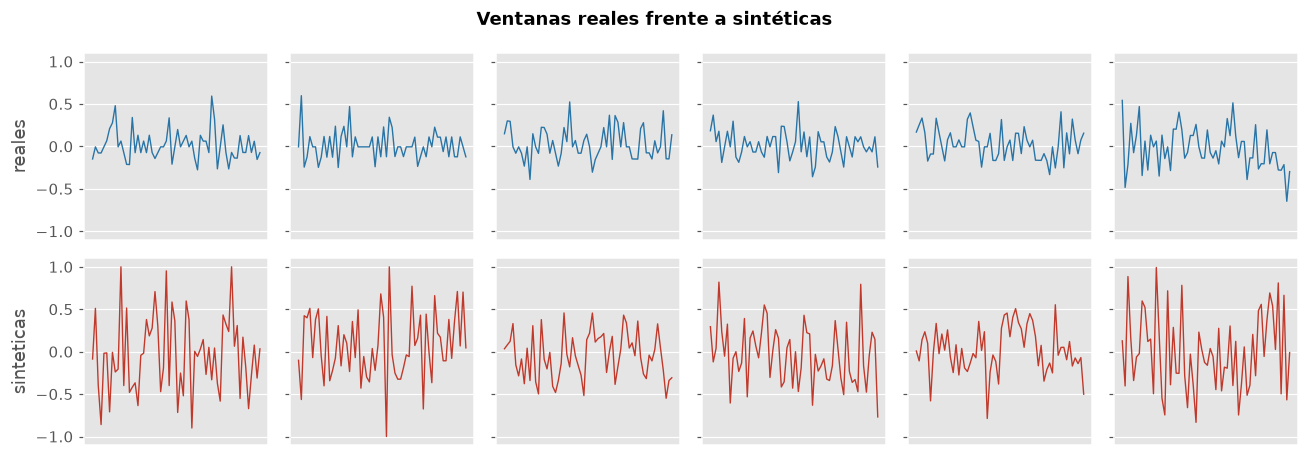

In [10]:
graficos.comparar_trayectorias(
    X_real, X_synth, "Ventanas reales frente a sintéticas", "06_trayectorias")
plt.show()

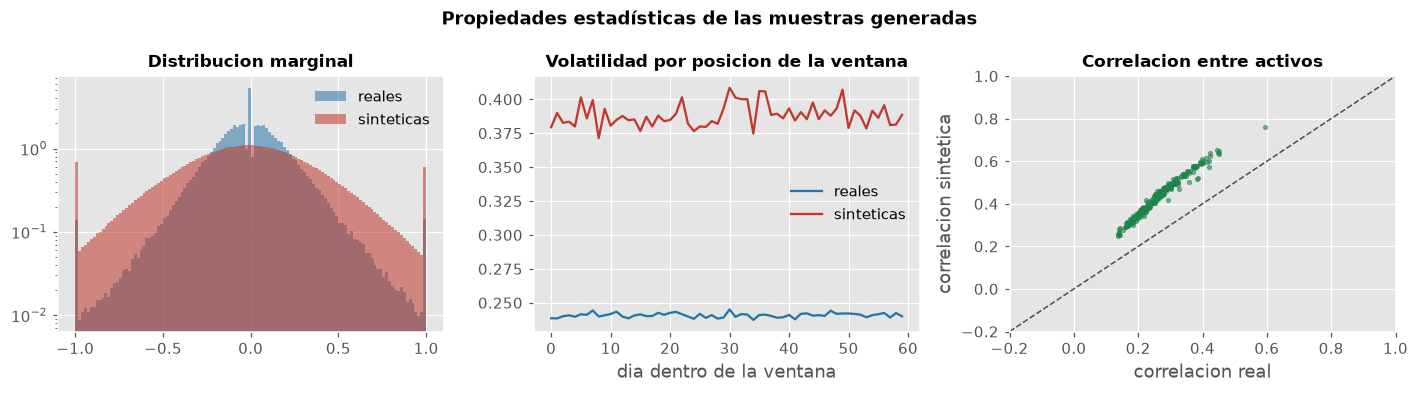

In [11]:
graficos.comparar_distribuciones(
    X_real, X_synth, "Propiedades estadísticas de las muestras generadas",
    "06_distribuciones")
plt.show()

La comparación numérica de las cuatro propiedades resume lo que muestran las dos
figuras anteriores.

In [12]:
corr_synth = np.corrcoef(X_synth.reshape(-1, n_activos).T)

comparacion = pd.DataFrame({
    "reales": {
        "desviacion tipica": float(X_real.std()),
        "curtosis": float(stats.kurtosis(X_real.ravel())),
        "asimetria": float(stats.skew(X_real.ravel())),
        "correlacion media entre activos": float(corr_real[triangulo].mean()),
    },
    "sinteticas": {
        "desviacion tipica": float(X_synth.std()),
        "curtosis": float(stats.kurtosis(X_synth.ravel())),
        "asimetria": float(stats.skew(X_synth.ravel())),
        "correlacion media entre activos": float(corr_synth[triangulo].mean()),
    },
})
display(comparacion.round(4))

,reales,sinteticas
desviacion tipica,0.2408,0.3918
curtosis,2.1970,0.0286
asimetria,0.0818,0.0110
correlacion media entre activos,0.2657,0.4347


La última comprobación mide cuanta novedad aportan las muestras. Un generador que
se límite a reproducir el conjunto de entrenamiento producira muestras muy
próximas a las reales, y en ese caso no puede aportar información que el
clasificador no tuviera ya.

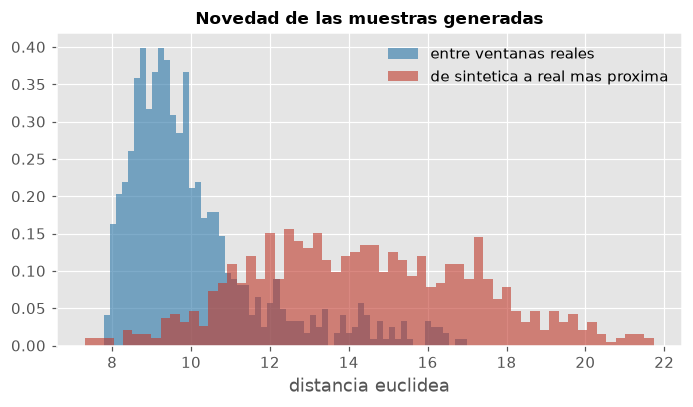

distancia_media_sintetica: 14.3646
distancia_media_real: 10.0454
ratio: 1.4300


In [13]:
fig, ax, resumen_novedad = graficos.novedad_vecino_mas_cercano(
    X_real, X_synth, "Novedad de las muestras generadas", "06_novedad")
plt.show()

for clave, valor in resumen_novedad.items():
    print(f"{clave}: {valor:.4f}")

El generador funciona, en el sentido de que no produce ruido: las trayectorias
tienen la forma irregular de una serie de rentabilidades y sólo un 2,1 % de los
valores toca los extremos del intervalo. Pero reproduce mal las tres propiedades
que el análisis exploratorio identificó como relevantes.

| Propiedad | Reales | Difusión |
|---|---|---|
| Desviación típica | 0,241 | 0,392 |
| Curtosis | 2,20 | 0,03 |
| Asimetría | 0,082 | 0,011 |
| Correlación media entre activos | 0,266 | 0,435 |

Las muestras son **más dispersas y de colas mucho más ligeras** que las reales.
La combinación es reveladora: la curtosis prácticamente nula indica que la
distribución generada se parece a una normal, mientras que la de las
rentabilidades reales tiene el exceso de curtosis característico de los mercados.
El modelo reparte la variabilidad de forma uniforme en lugar de concentrarla en
unos pocos episodios extremos, que es justamente donde vive el fenómeno que el
clasificador tiene que detectar.

El comportamiento de la correlación **es el opuesto al del cGAN**. Aquel
subestimaba la sincronía entre activos (0,182 frente a 0,266); éste la
sobrestima (0,435). Un exceso de correlación no es menos problemático que un
defecto: significa que las ventanas generadas mueven los veintitrés activos casi
al unísono, de modo que el drawdown de la cartera agregada resulta más extremo y
más frecuente de lo que corresponde.

La prueba de novedad da un cociente de **1,43**, el más alto de los cuatro
generadores. Las muestras están más lejos del conjunto de entrenamiento de lo
que dos ventanas reales distintas lo están entre sí. Leída junto a la tabla
anterior, esa distancia no es una virtud: no explora regiones plausibles que
falten en los datos, sino que se aleja de la distribución real.

## 7. Evaluación

Se ejecuta el protocolo común de evaluación. La función `barrido_ratios` entrena
el clasificador con el presupuesto real más cantidades crecientes de datos
sintéticos y repite cada configuración con varias semillas.

No conviene sustituir esta llamada por un bucle propio: es lo que asegura que los
resultados de los cuatro generadores se hayan obtenido en condiciones idénticas y
puedan compararse en el notebook final.

In [14]:
resultados, historias = experimento.barrido_ratios(
    "diffusion", X_real, y_real, X_synth, y_synth, X_val, y_val, X_test, y_test)

experimento.guardar_sinteticos("diffusion", X_synth, y_synth,
                               perdidas={"total": historial_perdida})
ruta = experimento.guardar_resultados(resultados, "diffusion")
print(f"\nResultados guardados en {ruta}")

resumen = experimento.resumir(resultados)
display(resumen.round(4))

  diffusion  ratio=0.00  semilla=42 PR-AUC(test)=0.3369 PR-AUC(val)=0.3280 F1=0.2770


  diffusion  ratio=0.00  semilla=43 PR-AUC(test)=0.2842 PR-AUC(val)=0.3579 F1=0.2659


  diffusion  ratio=0.00  semilla=44 PR-AUC(test)=0.1357 PR-AUC(val)=0.3070 F1=0.1687


  diffusion  ratio=0.00  semilla=45 PR-AUC(test)=0.1199 PR-AUC(val)=0.3166 F1=0.1709


  diffusion  ratio=0.00  semilla=46 PR-AUC(test)=0.2497 PR-AUC(val)=0.3471 F1=0.2315


...

  diffusion  ratio=4.00  semilla=44 PR-AUC(test)=0.1813 PR-AUC(val)=0.3423 F1=0.1923


  diffusion  ratio=4.00  semilla=45 PR-AUC(test)=0.2780 PR-AUC(val)=0.2814 F1=0.2101


  diffusion  ratio=4.00  semilla=46 PR-AUC(test)=0.2894 PR-AUC(val)=0.3298 F1=0.3081



Resultados guardados en C:\Users\piett\OneDrive\Desktop\Pietro\Master MIAX\Clases\5\tareas\B5-T1\results\tablas\resultados_diffusion.csv


,modelo,ratio,pr_auc_media,pr_auc_std,pr_auc_val_media,pr_auc_val_std,f1_media,f1_std,recall_media,precision_media,n_sinteticos
0,diffusion,0.00,0.2253,0.0944,0.3314,0.0211,0.2228,0.0512,0.3284,0.2041,0
1,diffusion,0.25,0.2542,0.0603,0.3066,0.0342,0.2290,0.0575,0.4403,0.1646,750
2,diffusion,0.50,0.2195,0.0589,0.2940,0.0165,0.2217,0.0329,0.3827,0.1581,1500
3,diffusion,1.00,0.1877,0.0465,0.2984,0.0357,0.2192,0.0686,0.3835,0.1608,3000
4,diffusion,2.00,0.1635,0.0280,0.3042,0.0189,0.1974,0.0169,0.4041,0.1316,6000
5,diffusion,4.00,0.2236,0.0550,0.3149,0.0258,0.2356,0.0491,0.4115,0.1695,12000


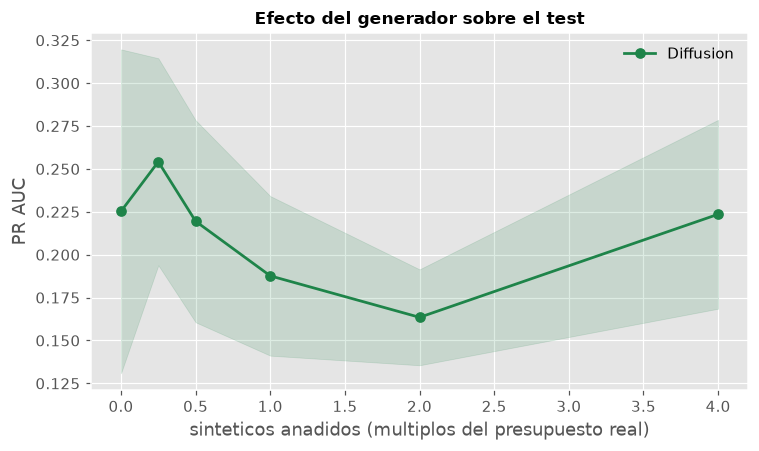

PR-AUC sin sintéticos: 0.2253
Mejor PR-AUC:          0.2542 con ratio 0.25


In [15]:
graficos.curva_ratios(
    resumen, titulo="Efecto del generador sobre el test",
    nombre_fichero="diffusion_curva_ratios")
plt.show()

base = resumen.loc[resumen["ratio"] == 0.0, "pr_auc_media"].iloc[0]
mejor = resumen.loc[resumen["pr_auc_media"].idxmax()]
print(f"PR-AUC sin sintéticos: {base:.4f}")
print(f"Mejor PR-AUC:          {mejor['pr_auc_media']:.4f} con ratio {mejor['ratio']:g}")

Las curvas de pérdida de cada entrenamiento del clasificador documentan la
convergencia exigida por el enunciado.

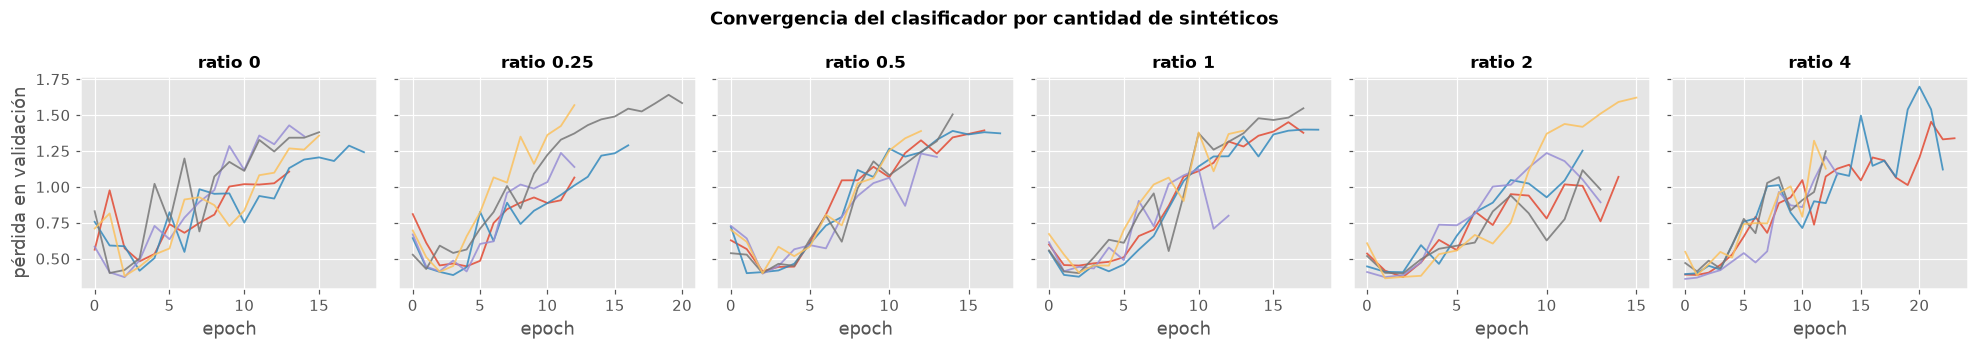

In [16]:
ratios_mostrados = sorted({r for r, _ in historias})
fig, axes = plt.subplots(1, len(ratios_mostrados),
                         figsize=(3.0 * len(ratios_mostrados), 3.2), sharey=True)
axes = np.atleast_1d(axes)

for ax, ratio in zip(axes, ratios_mostrados):
    for (r, semilla), historia in historias.items():
        if r == ratio:
            ax.plot(historia["val_loss"], linewidth=1.2, alpha=0.85)
    ax.set_title(f"ratio {ratio:g}")
    ax.set_xlabel("epoch")

axes[0].set_ylabel("pérdida en validación")
fig.suptitle("Convergencia del clasificador por cantidad de sintéticos",
             fontweight="bold")
fig.tight_layout()
graficos.guardar(fig, "diffusion_perdidas_clasificador")
plt.show()

## Conclusiones del notebook

1. **El modelo converge, pero sólo tras cambiar la formulación.** Con la
   parametrización clásica por ruido el error se estancaba en 0,80 sobre un
   máximo de 1,00 y el muestreo divergía, porque las rentabilidades diarias son
   casi ruido blanco y el epsilon no es recuperable. Estimando la ventana limpia
   el error baja a 0,338 y el proceso se estabiliza. Es el hallazgo técnico del
   notebook, y no es un detalle de implementación: dice algo sobre los datos.

2. **Reproduce mal las propiedades que importan.** Genera muestras un 63 % más
   dispersas que las reales, con curtosis prácticamente nula frente a 2,20, y
   con una correlación entre activos un 64 % por encima de la real. Reparte la
   variabilidad de forma uniforme en lugar de concentrarla en episodios
   extremos.

3. **Aporta novedad, pero de la que no sirve.** El cociente de 1,43 es el más
   alto de los cuatro generadores: sus muestras están más lejos del conjunto de
   entrenamiento que dos ventanas reales entre sí. Puesto junto al punto
   anterior, esa distancia mide alejamiento de la distribución, no exploración
   de regiones plausibles.

4. **Sobre el clasificador no aporta nada.** La mejor proporción es 0,25, con
   +0,029 en test y p = 0,215: no alcanza significación. En validación, que es
   la partición menos ruidosa, degrada en todas las proporciones, y a 0,5 la
   caída de −0,037 sí es significativa (p = 0,033). Se comporta como el
   generador por ruido del notebook 03, con la diferencia de que aquél al menos
   conservaba las propiedades estadísticas de los datos.

5. **Es con diferencia el más caro.** Dieciocho minutos de entrenamiento y dos
   más de muestreo, frente a los segundos del generador por ruido y los ocho
   minutos del cGAN, porque cada muestra exige recorrer los doscientos pasos del
   proceso inverso. Para el resultado obtenido, ese coste no se justifica.

6. **Qué habría que probar si hubiera más tiempo.** La red es densa sobre la
   ventana aplanada y trata las 1.380 componentes como independientes; una
   arquitectura convolucional sobre el eje temporal, o una U con conexiones de
   salto, tendría muchas más posibilidades de capturar el agrupamiento de
   volatilidad y la estructura entre activos que aquí se pierden. La limitación
   observada es de la arquitectura elegida, no de la difusión como familia.